# Reto 2 · Trayectorias: ¿los fenotipos evolucionan distinto?

**Notebook 05.** El reto pide "mostrar la evolución temporal" de cada fenotipo, y el pasaporte del `CLAUDE.md` exige un tercer sello: **el fenotipo evoluciona distinto**. Aquí se sigue la **DLCO** (la variable principal) de los dos fenotipos funcionales del notebook 04 desde la visita de los 3 meses hasta la visita anual, en las tres cohortes, y en Lleida hasta los 4 años.

| | |
|---|---|
| Fenotipos | Los del clustering **H3 del notebook 04** (las tres cohortes juntas): **F1 · función conservada** y **F2 · afectación funcional**. Se definieron con DLCO, FVC y FEV1 a los ~3 meses |
| Pacientes | Los 1.574 del horizonte H3. Cada paciente en una sola cohorte; las pruebas duplicadas entre registros cuentan una vez (reglas R06 y R07) |
| Eje temporal | **Días reales desde el alta** (no el número de visita), de 30 a 480 días: la ventana que comparten las tres cohortes (visitas de ~3, ~6 y ~12 meses) |
| Modelo | **Modelo lineal mixto**: `DLCO ~ fenotipo × log(tiempo) + cohorte`, con intercepto y pendiente aleatorios por paciente |
| Abandono | Quien deja de venir no es un paciente cualquiera. Se comprueba con **curvas por patrón de seguimiento** y se corrige con **pesos inversos de probabilidad (IPW)** |
| Más allá del año | Solo Lleida tiene datos: se presenta **aparte**, como extensión, sin extrapolar a las otras cohortes |
| Transiciones | Cada visita se reasigna a los **medoides fijos de H3**: ¿cuántos pacientes pasan de un fenotipo a otro? |

**Criterio del sello 3** (`config.yaml → trayectorias.criterio_sello`): los fenotipos "evolucionan distinto" si la **diferencia de DLCO F2 − F1 predicha a 12 meses** tiene un IC 95 % que excluye 0 en el modelo conjunto **y** en cada cohorte grande (CIBERESUCICOVID y Lleida). TENACITY se informa, pero es demasiado pequeña para decidir.

### Cómo leer este notebook (glosario)
- **Trayectoria:** cómo cambia la DLCO de un paciente con el tiempo. La del fenotipo es la media de las de sus pacientes.
- **Tiempo en escala logarítmica**, `lt = log(meses / 3)`: tras el alta la recuperación es rápida al principio y se frena después. En escala log esa curva se vuelve una recta. Con el tiempo centrado en 3 meses, `lt = 0` a los 3 meses, y el intercepto del modelo **es la DLCO a los 3 meses**.
- **Modelo mixto (efectos aleatorios):** cada paciente tiene su propio punto de partida (intercepto) y su propia velocidad de recuperación (pendiente). El modelo estima la media de cada fenotipo y cuánto varían los pacientes alrededor. Aprovecha a los pacientes con una sola medida, y sigue siendo válido si el abandono depende de la DLCO **ya observada** (supuesto MAR).
- **IPW:** a los pacientes que siguen viniendo pero se parecen a los que se fueron se les da más peso, para que la muestra se parezca a la de partida.
- **Regresión a la media:** si se elige a un grupo por tener un valor bajo en una prueba ruidosa, en la siguiente medida tenderá a subir aunque no cambie nada. Afecta a F2, que se definió en parte por una DLCO baja a 3 meses. Se comprueba en §7.

> **Privacidad.** Solo agregados: medias por grupo, coeficientes y recuentos. Las celdas y flujos con N < 10 se suprimen. No se dibujan trayectorias individuales.

## 0 · Entorno

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
from IPython.display import display
from scipy import stats
from sklearn.metrics import adjusted_rand_score

RAIZ = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent   # desde la raíz o desde Workflow/
sys.path.insert(0, str(RAIZ))
from src import carga, fenotipado_perfil as FP, privacidad, trayectorias as T

warnings.filterwarnings("ignore")              # avisos de convergencia de statsmodels: se comprueba `converged`

cfg = carga.cargar_config()
TR = cfg["trayectorias"]
PFC = FP.perfil(cfg, "fenotipado_comun")       # visitas, ventanas y Gower del notebook 04
COH = TR["cohortes"]
SEMILLA = cfg["semilla"]
N_MIN = cfg["privacidad"]["n_minimo_celda"]
DPM = cfg["limpieza"]["dias_por_mes"]
MREF = TR["mes_referencia"]
TRAMOS = TR["etiquetas_tramos"]
FEN = ["F1", "F2"]
NOMF = TR["nombres"]
C_FEN = {"F1": "#1b9e77", "F2": "#d95f02"}
ETQ = {"CIBERESUCICOVID": "CIBERESUCICOVID", "POSTCOVID_LLEIDA": "POSTCOVID-Lleida", "TENACITY": "TENACITY"}
U_DLCO = cfg["umbrales_clinicos"]["dlco_pct"]
DATOS = carga.RAIZ / cfg["rutas"]["procesados"]
FIG = RAIZ / cfg["rutas"]["figuras"]; FIG.mkdir(parents=True, exist_ok=True)
TAB = RAIZ / cfg["rutas"]["tablas"]; TAB.mkdir(parents=True, exist_ok=True)
PFX = "05_tray"
FORMULA = "valor ~ fenotipo * lt + cohorte"    # conjunto: la cohorte ajusta el nivel (TENACITY tiene la DLCO más alta)
FORMULA_C = "valor ~ fenotipo * lt"            # dentro de cada cohorte

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold", "axes.titlesize": 11.5,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 200)


def nota(fig, texto: str) -> None:
    """Pie de figura con N y cohortes."""
    fig.text(0.01, -0.01, texto, fontsize=8.5, color="0.35", va="top", ha="left")


def guardar(fig, nombre: str) -> None:
    fig.savefig(FIG / f"{PFX}_{nombre}.png", bbox_inches="tight", dpi=150)


def edad_aproximada(tramo) -> float:
    """Punto medio del tramo de edad (misma regla que los notebooks de modelos)."""
    if not isinstance(tramo, str) or tramo.startswith("<"):
        return np.nan
    if tramo.endswith("+"):
        return float(tramo[:-1]) + 2
    lo, hi = tramo.split("-")
    return (float(lo) + float(hi)) / 2


def media_ic(s: pd.Series) -> tuple[float, float, float]:
    """Media e IC 95 % (t de Student)."""
    s = s.dropna(); n = len(s)
    if n < 2:
        return s.mean(), np.nan, np.nan
    h = stats.t.ppf(0.975, n - 1) * s.std(ddof=1) / np.sqrt(n)
    return s.mean(), s.mean() - h, s.mean() + h


def fmt_ic(d: dict, dec: int = 1) -> str:
    return f"{d['estimacion']:+.{dec}f} [{d['ic_inf']:+.{dec}f} a {d['ic_sup']:+.{dec}f}]"

## 1 · Datos: quién tiene DLCO y cuándo

Se toma **cada medida válida de DLCO** (no excluida en la limpieza) entre 30 y 480 días tras el alta, del registro de la cohorte de análisis del paciente. Para describir y contar se agrupan los días en tres tramos sin solaparse: **T3** (30–150 días), **T6** (151–270) y **T12** (271–480). El modelo, en cambio, usa los **días exactos** de cada medida.

In [2]:
pacientes = pd.read_parquet(DATOS / "pacientes.parquet")
medidas = pd.read_parquet(DATOS / "medidas.parquet")
visitas_ten = pd.read_parquet(DATOS / "visitas_tenacity.parquet")
fen = pd.read_parquet(DATOS / TR["fenotipos"])
fen = fen[(fen["horizonte"] == TR["horizonte"]) & fen["cohorte_analisis"].isin(COH)].set_index("subject_id")
fenotipo, cohorte = fen["fenotipo"].astype(str), fen["cohorte_analisis"].astype(str)

L = T.tabla_larga(medidas, fenotipo, cohorte, TR["variable"], TR["ventana_comun_dias"], DPM, MREF)
L["tramo"] = T.tramo(L["dias"], TR["tramos_dias"], TRAMOS)
# Una cifra por paciente y tramo (media si hay dos medidas en el mismo tramo): para describir, no para modelar
PT = L.groupby(["subject_id", "cohorte", "fenotipo", "tramo"], observed=True).agg(
    valor=("valor", "mean"), meses=("meses", "mean")).reset_index()

n_por_paciente = L.groupby("subject_id").size()
filas = []
for c in COH:
    ids = fen.index[cohorte == c]
    n = n_por_paciente.reindex(ids).fillna(0)
    filas.append({"cohorte": ETQ[c], "pacientes H3": len(ids), "con ≥ 1 DLCO": int((n >= 1).sum()),
                  "con ≥ 2 DLCO (trayectoria)": int((n >= 2).sum()), "medidas de DLCO": int(n.sum())})
datos_resumen = pd.DataFrame(filas).set_index("cohorte")
datos_resumen.loc["Total"] = datos_resumen.sum()
datos_resumen.to_csv(TAB / f"{PFX}_datos.csv")
display(privacidad.suprimir_celdas(datos_resumen, N_MIN))

n_punto = PT.groupby(["cohorte", "fenotipo", "tramo"], observed=True).size().unstack("tramo").reindex(columns=TRAMOS)
n_punto.index = [f"{ETQ[c]} · {f}" for c, f in n_punto.index]
n_punto.loc["Las tres · F1"] = PT[PT["fenotipo"] == "F1"].groupby("tramo", observed=True).size()
n_punto.loc["Las tres · F2"] = PT[PT["fenotipo"] == "F2"].groupby("tramo", observed=True).size()
n_punto = n_punto.fillna(0).astype(int)
n_punto.to_csv(TAB / f"{PFX}_n_por_punto.csv")
print("Pacientes con DLCO en cada punto temporal (N en cada punto, como pide el CLAUDE.md):")
privacidad.suprimir_celdas(n_punto, N_MIN)

,pacientes H3,con ≥ 1 DLCO,con ≥ 2 DLCO (trayectoria),medidas de DLCO
cohorte,,,,
CIBERESUCICOVID,956,822,382,1318
POSTCOVID-Lleida,464,456,307,946
TENACITY,154,151,74,248
Total,1574,1429,763,2512


Pacientes con DLCO en cada punto temporal (N en cada punto, como pide el CLAUDE.md):


tramo,T3,T6,T12
CIBERESUCICOVID · F1,447,142,120
CIBERESUCICOVID · F2,329,123,91
POSTCOVID-Lleida · F1,203,105,87
POSTCOVID-Lleida · F2,248,162,138
TENACITY · F1,72,15,20
TENACITY · F2,79,30,31
Las tres · F1,722,262,227
Las tres · F2,656,315,260


**Lectura.** La mayoría tiene DLCO a los 3 meses y el número cae en las visitas siguientes: es el **abandono** (o la falta de prueba), que se estudia en §5. Los pacientes con una sola medida también entran en el modelo mixto: informan del nivel aunque no de la pendiente.

## 2 · Lo observado y lo que estima el modelo

Primero se ajusta el modelo mixto:
- **en las tres cohortes juntas**, con la cohorte como ajuste de nivel;
- **en cada cohorte por separado**.

La figura superpone:
- **puntos**: la media observada de cada fenotipo en cada tramo, con su IC 95 % y su N;
- **líneas y bandas**: la trayectoria media que estima el modelo, con su IC 95 %.

En el panel conjunto, la curva es la media ponderada por el tamaño de cada cohorte.

Modelo conjunto: 2512 medidas de 1429 pacientes; intercepto y pendiente aleatorios; convergió: True
  CIBERESUCICOVID: 1318 medidas; intercepto y pendiente aleatorios; convergió: True
  POSTCOVID-Lleida: 946 medidas; intercepto y pendiente aleatorios; convergió: True
  TENACITY: 248 medidas; intercepto y pendiente aleatorios; convergió: True


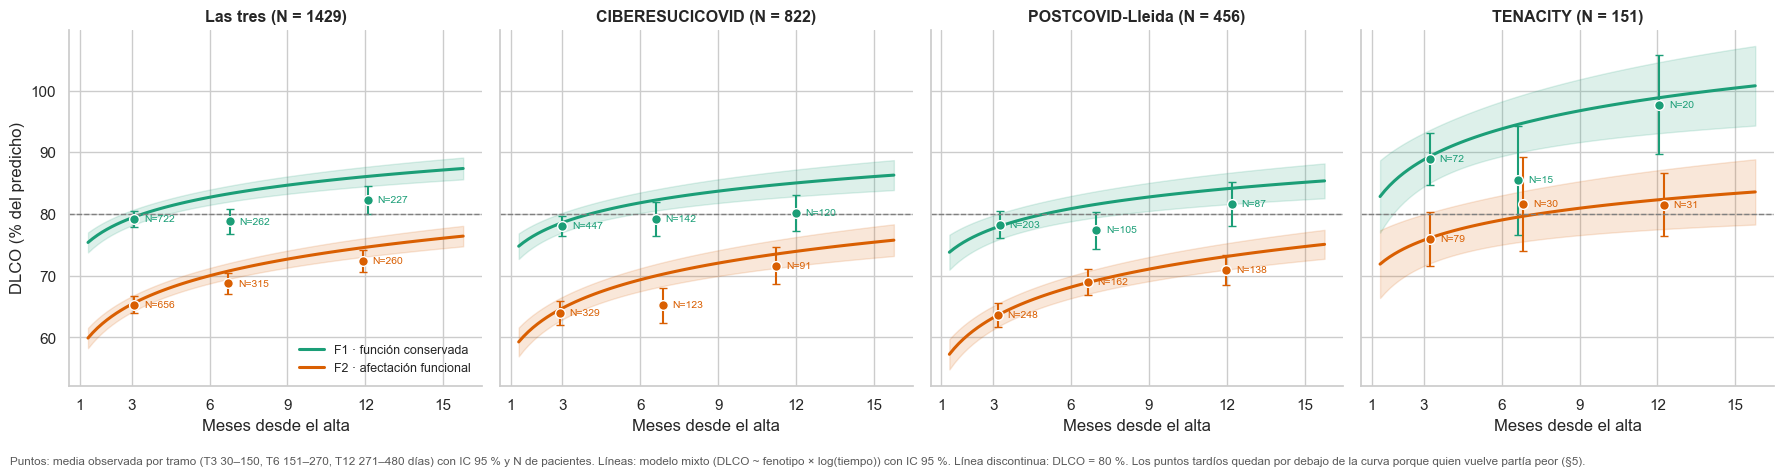

In [3]:
pesos_coh = cohorte.loc[L["subject_id"].unique()].value_counts(normalize=True).to_dict()
mixto, tipo_mixto = T.ajustar_mixto(L, FORMULA, TR["efectos_aleatorios"])
por_coh = {c: T.ajustar_mixto(L[L["cohorte"] == c], FORMULA_C, TR["efectos_aleatorios"]) for c in COH}
print(f"Modelo conjunto: {len(L)} medidas de {L['subject_id'].nunique()} pacientes; {tipo_mixto}; convergió: {mixto.converged}")
for c, (r, tipo) in por_coh.items():
    print(f"  {ETQ[c]}: {int(r.nobs)} medidas; {tipo}; convergió: {r.converged}")

rejilla = np.linspace(np.percentile(L["meses"], 2), TR["ventana_comun_dias"][1] / DPM, 80)   # sin extrapolar hacia el alta


def panel(ax, datos_pt: pd.DataFrame, res, pesos, titulo: str) -> None:
    """Medias observadas por tramo (con N) y curva del modelo con IC por fenotipo."""
    for f in FEN:
        pr = T.predicciones(res, [f], list(rejilla), MREF, pesos)
        ax.plot(rejilla, pr["estimacion"], color=C_FEN[f], lw=2.2, label=NOMF[f])
        ax.fill_between(rejilla, pr["ic_inf"], pr["ic_sup"], color=C_FEN[f], alpha=0.15)
        for t in TRAMOS:
            s = datos_pt[(datos_pt["fenotipo"] == f) & (datos_pt["tramo"] == t)]
            if len(s) < N_MIN:
                continue
            m, lo, hi = media_ic(s["valor"])
            x = s["meses"].median()
            ax.errorbar(x, m, yerr=[[m - lo], [hi - m]], fmt="o", color=C_FEN[f], mec="white", ms=7, capsize=3)
            ax.annotate(f"N={len(s)}", (x, m), textcoords="offset points", xytext=(7, 0),
                        ha="left", va="center", fontsize=7.5, color=C_FEN[f])
    ax.axhline(U_DLCO, color="0.5", ls="--", lw=1)
    ax.set_title(titulo); ax.set_xlabel("Meses desde el alta"); ax.set_xticks([1, 3, 6, 9, 12, 15])


fig, axes = plt.subplots(1, 4, figsize=(18, 4.6), sharey=True)
panel(axes[0], PT, mixto, pesos_coh, f"Las tres (N = {L['subject_id'].nunique()})")
for ax, c in zip(axes[1:], COH):
    panel(ax, PT[PT["cohorte"] == c], por_coh[c][0], None, f"{ETQ[c]} (N = {L.loc[L['cohorte'] == c, 'subject_id'].nunique()})")
axes[0].set_ylabel("DLCO (% del predicho)"); axes[0].legend(frameon=False, fontsize=9, loc="lower right")
nota(fig, "Puntos: media observada por tramo (T3 30–150, T6 151–270, T12 271–480 días) con IC 95 % y N de pacientes. "
          "Líneas: modelo mixto (DLCO ~ fenotipo × log(tiempo)) con IC 95 %. Línea discontinua: DLCO = 80 %. "
          "Los puntos tardíos quedan por debajo de la curva porque quien vuelve partía peor (§5).")
plt.tight_layout(); guardar(fig, "dlco_fenotipo"); plt.show()

## 3 · Resultados del modelo conjunto, en cifras clínicas

Los coeficientes de un modelo en escala logarítmica cuestan de leer. Por eso se traducen a lo que interesa en consulta:
- **DLCO media prevista** de cada fenotipo a los 3, 6, 9 y 12 meses;
- **diferencia F2 − F1** en cada momento: si se mantiene, se cierra o se abre;
- **cuánto gana cada fenotipo** entre los 3 y los 12 meses.

Todas las cifras llevan su IC 95 %. Los coeficientes originales se muestran al final.

In [4]:
MESES = TR["meses_prediccion"]
pred = T.predicciones(mixto, FEN, MESES, MREF, pesos_coh)
tabla_pred = pred.assign(valor=lambda d: d.apply(lambda r: f"{r.estimacion:.1f} [{r.ic_inf:.1f}–{r.ic_sup:.1f}]", axis=1)) \
    .pivot(index="meses", columns="fenotipo", values="valor").rename(columns=NOMF)
dif = T.diferencias(mixto, "F1", "F2", MESES, MREF)
tabla_pred["Diferencia F2 − F1"] = [fmt_ic(r) for r in dif.to_dict("records")]
tabla_pred.index = [f"{m} meses" for m in tabla_pred.index]
tabla_pred.to_csv(TAB / f"{PFX}_predicciones.csv")
print("DLCO media prevista (% del predicho) y diferencia entre fenotipos, con IC 95 %:")
display(tabla_pred)

g1, g2 = T.ganancia(mixto, "F1", 3, 12, MREF), T.ganancia(mixto, "F2", 3, 12, MREF)
x_rec = (T.vector_contraste(mixto, {"fenotipo": "F2", "lt": np.log(12 / MREF)}) - T.vector_contraste(mixto, {"fenotipo": "F2", "lt": 0})) \
    - (T.vector_contraste(mixto, {"fenotipo": "F1", "lt": np.log(12 / MREF)}) - T.vector_contraste(mixto, {"fenotipo": "F1", "lt": 0}))
g_dif = T.combinacion(mixto, x_rec)
ganancias = pd.DataFrame({"ganancia de DLCO entre 3 y 12 meses (puntos)": [fmt_ic(g1), fmt_ic(g2), fmt_ic(g_dif)],
                          "p": [f"{g1['p']:.2g}", f"{g2['p']:.2g}", f"{g_dif['p']:.2g}"]},
                         index=[NOMF["F1"], NOMF["F2"], "F2 − F1 (recuperación adicional de F2)"])
ganancias.to_csv(TAB / f"{PFX}_ganancias.csv")
display(ganancias)

re_cov = mixto.cov_re
variab = {"DE del nivel a 3 meses entre pacientes": np.sqrt(re_cov.iloc[0, 0]),
          "DE residual (variabilidad de la prueba + cambios no explicados)": np.sqrt(mixto.scale)}
if re_cov.shape[0] > 1:
    variab["DE de la ganancia 3→12 meses entre pacientes"] = np.sqrt(re_cov.iloc[1, 1]) * np.log(12 / MREF)
print("Variabilidad entre pacientes (puntos de DLCO):", {k: round(v, 1) for k, v in variab.items()})

coef = pd.DataFrame({"coeficiente": mixto.fe_params, "EE": mixto.bse_fe, "p": mixto.pvalues[mixto.fe_params.index]}).round(3)
coef.index = coef.index.str.replace("fenotipo[T.F2]", "F2").str.replace("cohorte[T.", "cohorte ").str.replace("]", "")
coef.to_csv(TAB / f"{PFX}_coeficientes.csv")
print("Coeficientes originales (Intercept = DLCO de F1 a 3 meses en CIBERESUCICOVID; lt = log(meses/3)):")
coef

DLCO media prevista (% del predicho) y diferencia entre fenotipos, con IC 95 %:


fenotipo,F1 · función conservada,F2 · afectación funcional,Diferencia F2 − F1
3 meses,79.4 [78.2–80.6],65.4 [64.1–66.7],-14.0 [-15.8 a -12.2]
6 meses,82.7 [81.5–84.0],70.0 [68.7–71.3],-12.7 [-14.5 a -11.0]
9 meses,84.7 [83.3–86.1],72.7 [71.3–74.1],-12.0 [-14.0 a -10.0]
12 meses,86.1 [84.5–87.6],74.6 [73.1–76.1],-11.5 [-13.6 a -9.3]


,ganancia de DLCO entre 3 y 12 meses (puntos),p
F1 · función conservada,+6.7 [+5.3 a +8.0],2.1e-22
F2 · afectación funcional,+9.2 [+8.0 a +10.4],8.4e-49
F2 − F1 (recuperación adicional de F2),+2.5 [+0.7 a +4.3],0.0061


Variabilidad entre pacientes (puntos de DLCO): {'DE del nivel a 3 meses entre pacientes': np.float64(15.6), 'DE residual (variabilidad de la prueba + cambios no explicados)': np.float64(6.9), 'DE de la ganancia 3→12 meses entre pacientes': np.float64(6.7)}
Coeficientes originales (Intercept = DLCO de F1 a 3 meses en CIBERESUCICOVID; lt = log(meses/3)):


,coeficiente,EE,p
Intercept,78.604,0.703,0.000
F2,-13.987,0.907,0.000
cohorte POSTCOVID_LLEIDA,-1.074,0.960,0.264
cohorte TENACITY,10.550,1.459,0.000
lt,4.825,0.495,0.000
F2:lt,1.824,0.665,0.006


**Cómo leerlo.**
- **Por qué la curva queda por encima de los puntos tardíos de F1.** Los puntos son medias de **quien volvió**, y quien vuelve partía peor (§5). El modelo mixto usa también a los pacientes con una sola medida (sobre todo los que estaban mejor a 3 meses). Supone que su evolución habría sido como la de pacientes parecidos que sí volvieron (supuesto MAR). Así corrige ese sesgo, y por eso estima una recuperación algo mayor que la que sugieren las medias brutas.
- La **diferencia a 3 meses** se explica en buena parte por construcción: F2 se definió por tener peor función en esa visita.
- Lo que aporta información nueva es **qué pasa después**:
  - si la diferencia a 12 meses sigue siendo clara, los fenotipos no convergen;
  - si F2 gana más puntos que F1, recupera parte de la distancia, pero sin alcanzar a F1.
- La **variabilidad entre pacientes** es grande comparada con las diferencias medias. El fenotipo describe bien a grupos, pero un paciente concreto puede apartarse mucho de la curva de su grupo.

## 4 · ¿Se repite en cada cohorte?

Es la parte "viaja" de este sello: el mismo modelo, ajustado **por separado en cada cohorte**.

In [5]:
filas = []
for nombre, (res, tipo) in [("Las tres (conjunto)", (mixto, tipo_mixto)), *[(ETQ[c], por_coh[c]) for c in COH]]:
    d = T.diferencias(res, "F1", "F2", [3, 12], MREF).set_index("meses")
    a, b = T.ganancia(res, "F1", 3, 12, MREF), T.ganancia(res, "F2", 3, 12, MREF)
    n_pac = L["subject_id"].nunique() if nombre.startswith("Las tres") else L.loc[L["cohorte"].map(ETQ) == nombre, "subject_id"].nunique()
    filas.append({"cohorte": nombre, "pacientes": n_pac, "efectos aleatorios": tipo,
                  "F2 − F1 a 3 m": fmt_ic(d.loc[3].to_dict()), "F2 − F1 a 12 m": fmt_ic(d.loc[12].to_dict()),
                  "ganancia F1 3→12": f"{a['estimacion']:+.1f}", "ganancia F2 3→12": f"{b['estimacion']:+.1f}",
                  "_sup12": d.loc[12, "ic_sup"]})
replica = pd.DataFrame(filas).set_index("cohorte")
replica["diferencia a 12 m con IC < 0"] = np.where(replica["_sup12"] < 0, "sí", "no")
replica = replica.drop(columns="_sup12")
replica.to_csv(TAB / f"{PFX}_replica_cohortes.csv")
replica

,pacientes,efectos aleatorios,F2 − F1 a 3 m,F2 − F1 a 12 m,ganancia F1 3→12,ganancia F2 3→12,diferencia a 12 m con IC < 0
cohorte,,,,,,,
Las tres (conjunto),1429,intercepto y pendiente aleatorios,-14.0 [-15.8 a -12.2],-11.5 [-13.6 a -9.3],+6.7,+9.2,sí
CIBERESUCICOVID,822,intercepto y pendiente aleatorios,-13.9 [-16.3 a -11.4],-11.1 [-14.2 a -8.0],+6.4,+9.2,sí
POSTCOVID-Lleida,456,intercepto y pendiente aleatorios,-14.5 [-17.3 a -11.6],-11.0 [-14.3 a -7.7],+6.5,+9.9,sí
TENACITY,151,intercepto y pendiente aleatorios,-13.0 [-19.1 a -7.0],-16.5 [-24.0 a -9.0],+10.0,+6.5,sí


## 5 · Abandono informativo

El notebook 01 mostró que **quien no vuelve al año partía con mejor DLCO**. Si los que siguen viniendo son los que están peor, la curva media de los que quedan **infravalora la recuperación**. Se ataca de dos maneras:

1. **Patrón de seguimiento:** se agrupa a los pacientes según en qué tramos tienen DLCO y se compara su punto de partida. En TENACITY, el reclutamiento sigue abierto: a quien **aún no le toca** la visita anual (regla R12) se le separa, porque no es una pérdida.
2. **IPW:** se modela la probabilidad de tener DLCO en T6 y en T12 con lo que se sabía a los 3 meses (DLCO a 3 m, fenotipo, cohorte, edad, sexo y estancia). Cada medida tardía se pondera por la inversa de esa probabilidad (pesos estabilizados y recortados en el P99) en un **GEE**: un modelo de la media poblacional con errores robustos. Se compara con el modelo mixto y con el mismo GEE sin pesos.

,pacientes,% F2,DLCO a 3 m (media),N con DLCO a 3 m
patrón (tramos con DLCO),,,,
T3,635,39.4,76.6,635
T3 + T6 + T12,296,54.7,67.7,296
T3 + T6,248,54.8,66.4,248
T3 + T12,162,52.5,72.4,162
ninguno,143,49.7,NaN,0
TENACITY: aún no le toca la visita anual,39,61.5,85.0,37
T6,22,54.5,NaN,0
T12,21,52.4,NaN,0
T6 + T12,<10,NaN,NaN,0


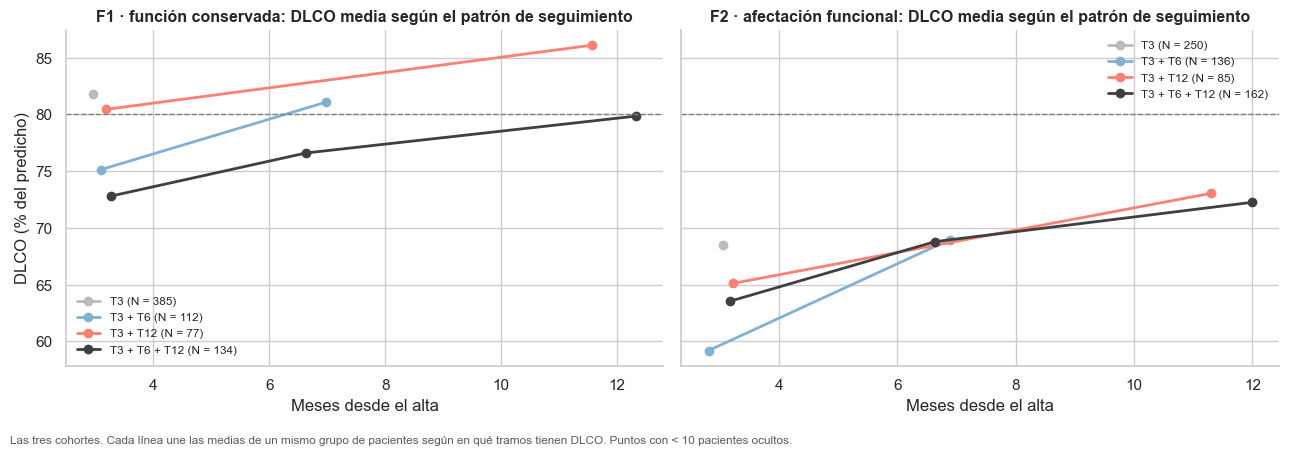

In [6]:
presencia = PT.pivot_table(index="subject_id", columns="tramo", values="valor", aggfunc="size", observed=False) \
    .reindex(index=fen.index, columns=TRAMOS).fillna(0) > 0
patron = T.patron_seguimiento(presencia)
ten = fen.index[cohorte == "TENACITY"]
no_toca = set(visitas_ten.loc[(visitas_ten["visita"] == "A1") & (visitas_ten["estado"] == "no_le_toca"), "subject_id"]) & set(ten)
patron[patron.index.isin(no_toca) & ~presencia["T12"]] = "TENACITY: aún no le toca la visita anual"

dlco3 = PT[PT["tramo"] == "T3"].set_index("subject_id")["valor"]
filas = []
for p_, ids in patron.groupby(patron).groups.items():
    v3 = dlco3.reindex(ids).dropna()
    filas.append({"patrón (tramos con DLCO)": p_, "pacientes": len(ids), "% F2": round(100 * (fenotipo.loc[ids] == "F2").mean(), 1),
                  "DLCO a 3 m (media)": round(v3.mean(), 1) if len(v3) >= N_MIN else np.nan, "N con DLCO a 3 m": len(v3)})
patrones = pd.DataFrame(filas).set_index("patrón (tramos con DLCO)").sort_values("pacientes", ascending=False)
patrones.loc[patrones["pacientes"] < N_MIN, ["% F2", "DLCO a 3 m (media)"]] = np.nan   # grupos pequeños: sin descriptivos
patrones.to_csv(TAB / f"{PFX}_patrones.csv")
display(privacidad.suprimir_celdas(patrones, N_MIN, ["pacientes", "N con DLCO a 3 m"]))

principales = ["T3", "T3 + T6", "T3 + T12", "T3 + T6 + T12"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), sharey=True)
for ax, f in zip(axes, FEN):
    for p_, color in zip(principales, ["#bbbbbb", "#80b1d3", "#fb8072", "#3f3f3f"]):
        ids = patron.index[(patron == p_) & (fenotipo == f)]
        xs, ys = [], []
        for t in TRAMOS:
            s = PT[(PT["subject_id"].isin(ids)) & (PT["tramo"] == t)]
            if len(s) >= N_MIN:
                xs.append(s["meses"].median()); ys.append(s["valor"].mean())
        if xs:
            ax.plot(xs, ys, "o-", color=color, lw=2, label=f"{p_} (N = {len(ids)})")
    ax.axhline(U_DLCO, color="0.5", ls="--", lw=1)
    ax.set_title(f"{NOMF[f]}: DLCO media según el patrón de seguimiento"); ax.set_xlabel("Meses desde el alta")
    ax.legend(frameon=False, fontsize=8.5)
axes[0].set_ylabel("DLCO (% del predicho)")
nota(fig, "Las tres cohortes. Cada línea une las medias de un mismo grupo de pacientes según en qué tramos tienen DLCO. "
          "Puntos con < 10 pacientes ocultos.")
plt.tight_layout(); guardar(fig, "patrones_abandono"); plt.show()

In [7]:
p = pacientes.set_index("subject_id").loc[fen.index]
B = pd.DataFrame({"valor_T3": dlco3.reindex(fen.index), "edad": p["edad_tramo5"].map(edad_aproximada),
                  "sexo": p["sexo"].astype(float), "estancia_hosp_dias": p["estancia_hosp_dias"].astype(float)}, index=fen.index)
X_ipw = pd.concat([B[TR["ipw"]["covariables"]], (fenotipo == "F2").astype(float).rename("F2"),
                   pd.get_dummies(cohorte, drop_first=True, dtype=float)], axis=1)
pesos, filas = {"T3": pd.Series(1.0, index=fen.index)}, []
for t in ["T6", "T12"]:
    en_riesgo = ~fen.index.isin(no_toca) if t == "T12" else np.ones(len(fen), bool)   # 'no le toca' no es abandono
    obs = presencia.loc[en_riesgo, t]
    pesos[t] = T.pesos_ipw(X_ipw[en_riesgo], obs, TR["ipw"]["recorte_percentil"])
    w = pesos[t].dropna()
    filas.append({"tramo": t, "pacientes en riesgo": int(en_riesgo.sum()), "% con DLCO": round(100 * obs.mean(), 1),
                  "peso: mediana": round(w.median(), 2), "peso: P1–P99": f"{w.quantile(0.01):.2f}–{w.quantile(0.99):.2f}"})
display(pd.DataFrame(filas).set_index("tramo"))

L["peso"] = [pesos[str(t)].get(s, np.nan) for s, t in zip(L["subject_id"], L["tramo"])]
print(f"Medidas sin peso (se les da 1): {int(L['peso'].isna().sum())}")
L["peso"] = L["peso"].fillna(1.0)

gee0 = T.ajustar_gee(L, FORMULA)
gee_w = T.ajustar_gee(L, FORMULA, L["peso"].to_numpy())
filas = []
for nombre, res in [("Modelo mixto (principal)", mixto), ("GEE sin pesos (solo lo observado)", gee0), ("GEE con IPW", gee_w)]:
    pr = T.predicciones(res, FEN, [3, 12], MREF, pesos_coh).set_index(["fenotipo", "meses"])["estimacion"]
    d12 = T.diferencias(res, "F1", "F2", [12], MREF).iloc[0].to_dict()
    filas.append({"modelo": nombre, "F1 a 12 m": round(pr[("F1", 12)], 1), "F2 a 12 m": round(pr[("F2", 12)], 1),
                  "F2 − F1 a 12 m": fmt_ic(d12),
                  "ganancia F1 3→12": round(T.ganancia(res, "F1", 3, 12, MREF)["estimacion"], 1),
                  "ganancia F2 3→12": round(T.ganancia(res, "F2", 3, 12, MREF)["estimacion"], 1)})
abandono = pd.DataFrame(filas).set_index("modelo")
abandono.to_csv(TAB / f"{PFX}_abandono_ipw.csv")
abandono

,pacientes en riesgo,% con DLCO,peso: mediana,peso: P1–P99
tramo,,,,
T6,1574,36.7,0.82,0.47–2.72
T12,1533,31.6,0.81,0.49–2.12


Medidas sin peso (se les da 1): 2


,F1 a 12 m,F2 a 12 m,F2 − F1 a 12 m,ganancia F1 3→12,ganancia F2 3→12
modelo,,,,,
Modelo mixto (principal),86.1,74.6,-11.5 [-13.6 a -9.3],6.7,9.2
GEE sin pesos (solo lo observado),82.5,72.5,-10.0 [-12.6 a -7.3],3.8,7.6
GEE con IPW,84.8,74.5,-10.4 [-13.2 a -7.6],5.6,9.2


**Cómo leerlo.**
- **El GEE sin pesos** promedia lo que se ve. Si el abandono es informativo, sesga la curva: quien se queda está peor.
- **El modelo mixto** usa todas las medidas de cada paciente y corrige el abandono que depende de la DLCO ya medida.
- **El GEE con IPW** corrige el abandono que depende de las covariables del modelo de pesos.

Si los tres cuentan la misma historia, la conclusión no depende del abandono. Ninguno corrige un abandono que dependa de la DLCO futura **no** observada (MNAR): esa limitación queda declarada.

## 6 · Sensibilidad: regresión a la media y FVC

1. **Sin la medida que define el fenotipo.** F2 se eligió en parte por una DLCO baja a los 3 meses. Por puro ruido de la prueba, ese grupo "mejoraría" en la siguiente medida aunque nada cambiara. Para descartarlo, se repite el modelo **solo con las medidas de T6 y T12**, que no intervinieron en la definición. Si F2 sigue por debajo a 12 meses, la diferencia no es un artefacto.
2. **FVC.** La partición la sostiene sobre todo la espirometría (notebook 04). Se repite el modelo con la FVC como variable secundaria.

In [8]:
L_post = L[L["tramo"] != "T3"]
mixto_post, tipo_post = T.ajustar_mixto(L_post, FORMULA, TR["efectos_aleatorios"])
L_fvc = T.tabla_larga(medidas, fenotipo, cohorte, TR["secundaria"], TR["ventana_comun_dias"], DPM, MREF)
mixto_fvc, tipo_fvc = T.ajustar_mixto(L_fvc, FORMULA, TR["efectos_aleatorios"])

filas = []
for nombre, res, tipo, datos in [("DLCO, principal", mixto, tipo_mixto, L),
                                 ("DLCO sin la medida de 3 meses (solo T6 y T12)", mixto_post, tipo_post, L_post),
                                 ("FVC, principal", mixto_fvc, tipo_fvc, L_fvc)]:
    d = T.diferencias(res, "F1", "F2", [6, 12], MREF).set_index("meses")
    filas.append({"análisis": nombre, "medidas": len(datos), "pacientes": datos["subject_id"].nunique(), "efectos aleatorios": tipo,
                  "F2 − F1 a 6 m": fmt_ic(d.loc[6].to_dict()), "F2 − F1 a 12 m": fmt_ic(d.loc[12].to_dict()),
                  "ganancia F1 3→12": round(T.ganancia(res, "F1", 3, 12, MREF)["estimacion"], 1),
                  "ganancia F2 3→12": round(T.ganancia(res, "F2", 3, 12, MREF)["estimacion"], 1)})
sensibilidad = pd.DataFrame(filas).set_index("análisis")
sensibilidad.to_csv(TAB / f"{PFX}_sensibilidad.csv")
sensibilidad

,medidas,pacientes,efectos aleatorios,F2 − F1 a 6 m,F2 − F1 a 12 m,ganancia F1 3→12,ganancia F2 3→12
análisis,,,,,,,
"DLCO, principal",2512,1429,intercepto y pendiente aleatorios,-12.7 [-14.5 a -11.0],-11.5 [-13.6 a -9.3],6.7,9.2
DLCO sin la medida de 3 meses (solo T6 y T12),1082,760,intercepto y pendiente aleatorios,-11.2 [-13.8 a -8.6],-10.9 [-13.4 a -8.5],7.6,8.3
"FVC, principal",2804,1558,intercepto y pendiente aleatorios,-22.4 [-23.7 a -21.2],-19.2 [-21.0 a -17.5],3.7,10.1


## 7 · Transiciones: ¿cuántos pacientes cambian de fenotipo?

Las trayectorias medias no dicen si los pacientes **cambian de grupo**. Para saberlo, cada visita posterior se asigna al **medoide fijo de H3** (el paciente "típico" de F1 y de F2 del notebook 04). Se usa la misma distancia de Gower, con los mismos rangos y pesos, y la DLCO, FVC y FEV1 de esa visita.

Es lo que pide el `CLAUDE.md`, y evita el problema de las transiciones del notebook 04: allí cada horizonte volvía a agrupar con otras variables, así que sus etiquetas no eran comparables.

Primero se reconstruye el clustering H3 del notebook 04 y se comprueba que da **exactamente** las mismas etiquetas.

In [9]:
partes = [FP.construir_variables(medidas, pacientes, cfg, PFC, "H3", c) for c in COH]
t3 = pd.concat([t for t, _ in partes]); COLS = partes[0][1]
t3 = t3[t3[COLS].notna().any(axis=1)]
X3 = t3[COLS].to_numpy(float)
R, W, CAT = FP.parametros_gower(COLS, PFC)
lab, med = FP.pam(FP.gower(X3, None, R, W, CAT), len(FEN), SEMILLA)
lab, med = FP.ordenar_por_dlco(lab, med, t3["dlco_T3"].to_numpy(float))
etq_h3 = pd.Series([f"F{c + 1}" for c in lab], index=t3.index)
coinciden = (etq_h3 == fenotipo.reindex(etq_h3.index)).mean()
assert coinciden == 1.0, f"el clustering reconstruido no coincide con el del notebook 04 ({coinciden:.1%})"
MEDOIDES = X3[med]
print(f"Clustering H3 reconstruido: {len(t3)} pacientes, etiquetas idénticas al notebook 04 ({coinciden:.0%}).")
medoides_tabla = pd.DataFrame(MEDOIDES, index=FEN, columns=[c.replace("_T3", "").upper() + " a 3 m" for c in COLS]).round(1)
print("Medoides de H3 (pacientes «típicos» de cada fenotipo; vacío = el medoide no tiene esa prueba):")
display(medoides_tabla.astype(object).where(medoides_tabla.notna(), "sin dato"))

PF_EXT = {**PFC, "visitas": {**PFC["visitas"], **TR["transiciones"]["visita_extra_lleida"]}}


def asignar_visita(cohorte_: str, visita: str) -> pd.Series:
    """Fenotipo de cada paciente en `visita`: medoide H3 más cercano con su DLCO/FVC/FEV1 de esa visita."""
    vars_ = [c.rsplit("_", 1)[0] for c in COLS]
    m = FP.medidas_por_visita(medidas, PF_EXT, cohorte_, vars_)
    # solo pacientes de esta cohorte de análisis (un fusionado tiene medidas de dos registros, pero cuenta en uno)
    m = m[(m["visita_c"] == visita) & m["subject_id"].isin(fen.index[cohorte == cohorte_])].sort_values("dias_alta")
    v = m.groupby(["subject_id", "variable"])["valor"].first().unstack().reindex(columns=vars_)
    v = v[v.notna().any(axis=1)]
    if v.empty:
        return pd.Series(dtype=str)
    return pd.Series([f"F{c + 1}" for c in FP.asignar_medoides(FP.gower(v.to_numpy(float), MEDOIDES, R, W, CAT))], index=v.index)


asig = {t: pd.concat([asignar_visita(c, t) for c in COH]) for t in TR["transiciones"]["visitas"]}
assert (asig["T3"] == fenotipo.reindex(asig["T3"].index)).mean() > 0.95, "la reasignación en T3 debería reproducir H3"
asig["T24"] = asignar_visita("POSTCOVID_LLEIDA", "T24")
ETIQ = pd.DataFrame(asig)

filas, tablas_tr = [], {}
for a, b in [("T3", "T6"), ("T6", "T12"), ("T3", "T12"), ("T12", "T24")]:
    for nombre, ids in [("Las tres", ETIQ.index), *[(ETQ[c], ETIQ.index[cohorte.reindex(ETIQ.index) == c]) for c in COH]]:
        if b == "T24" and nombre != ETQ["POSTCOVID_LLEIDA"]:
            continue                                        # a 24 meses solo hay Lleida
        par = ETIQ.loc[ids, [a, b]].dropna()
        if len(par) < N_MIN:
            continue
        ct = pd.crosstab(par[a], par[b]).reindex(index=FEN, columns=FEN, fill_value=0)
        tablas_tr[(a, b, nombre)] = ct
        filas.append({"transición": f"{a} → {b}", "cohorte": nombre, "pacientes": len(par),
                      # si cambian de fenotipo menos de N_MIN pacientes, el % los delataría: se suprime
                      "% que sigue en su fenotipo": (round(100 * np.trace(ct.values) / len(par), 1)
                                                     if not 0 < len(par) - np.trace(ct.values) < N_MIN else np.nan),
                      "F1 → F2": privacidad.proporcion_segura(int(ct.loc["F1", "F2"]), int(ct.loc["F1"].sum()), N_MIN),
                      "F2 → F1": privacidad.proporcion_segura(int(ct.loc["F2", "F1"]), int(ct.loc["F2"].sum()), N_MIN)})
transiciones = pd.DataFrame(filas).set_index(["transición", "cohorte"])
transiciones.to_csv(TAB / f"{PFX}_transiciones.csv")
transiciones

Clustering H3 reconstruido: 1574 pacientes, etiquetas idénticas al notebook 04 (100%).
Medoides de H3 (pacientes «típicos» de cada fenotipo; vacío = el medoide no tiene esa prueba):


,DLCO a 3 m,FVC a 3 m,FEV1 a 3 m
F1,sin dato,96.0,100.0
F2,sin dato,71.0,sin dato


pacientes  % que sigue en su fenotipo         F1 → F2           F2 → F1
transición cohorte                                                                                  
T3 → T6    Las tres                638                        80.4  20/304 (6.6 %)  105/334 (31.4 %)
           CIBERESUCICOVID         318                        80.8  11/180 (6.1 %)   50/138 (36.2 %)
           POSTCOVID-Lleida        272                        79.4         <10/109   48/163 (29.4 %)
           TENACITY                 48                         NaN          <10/15            <10/33
T6 → T12   Las tres                345                        85.5  17/200 (8.5 %)   33/145 (22.8 %)
           CIBERESUCICOVID         133                        82.0          <10/89    16/44 (36.4 %)
           POSTCOVID-Lleida        188                        88.8         <10/100    16/88 (18.2 %)
           TENACITY                 24                         NaN          <10/11            <10/13
T3 → T12   Las tres                534                        76.0  20/253 (7.9 %)  108/281 (38.4 %)
           CIBERESUCICOVID         259                        76.1  13/145 (9.0 %)   49/114 (43.0 %)
           POSTCOVID-Lleida        222                        73.4          <10/86   54/136 (39.7 %)
           TENACITY                 53                         NaN          <10/22            <10/31
T12 → T24  POSTCOVID-Lleida        176                        86.4         <10/106    16/70 (22.9 %)

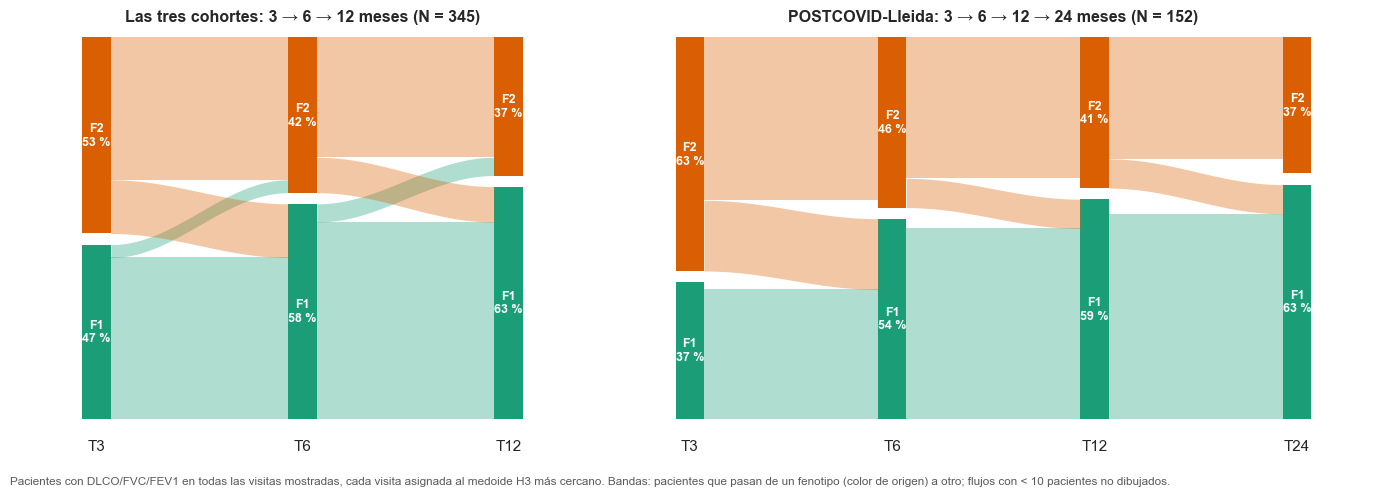

In [10]:
def aluvial(ax, etiquetas: pd.DataFrame, titulo: str) -> None:
    """Diagrama aluvial: bloques = % en cada fenotipo por visita; bandas = flujos entre visitas consecutivas.
    Los flujos de menos de N_MIN pacientes no se dibujan (privacidad)."""
    cols, n, hueco, ancho = list(etiquetas.columns), len(etiquetas), 0.03, 0.14
    pos = {}
    for j, c in enumerate(cols):
        y0 = 0.0
        for f in FEN:
            k = int((etiquetas[c] == f).sum()); h = k / n
            pos[(j, f)] = y0
            ax.add_patch(Rectangle((j - ancho / 2, y0), ancho, h, color=C_FEN[f], lw=0))
            ax.text(j, y0 + h / 2, f"{f}\n{100 * h:.0f} %", ha="center", va="center", fontsize=9, color="white", weight="bold")
            y0 += h + hueco
    for j in range(len(cols) - 1):
        sal = {f: pos[(j, f)] for f in FEN}; ent = {f: pos[(j + 1, f)] for f in FEN}
        for fa in FEN:
            for fb in FEN:
                k = int(((etiquetas[cols[j]] == fa) & (etiquetas[cols[j + 1]] == fb)).sum()); h = k / n
                if k >= N_MIN:
                    x = np.linspace(j + ancho / 2, j + 1 - ancho / 2, 60)
                    s = (1 - np.cos(np.pi * (x - x[0]) / (x[-1] - x[0]))) / 2
                    lo = sal[fa] + (ent[fb] - sal[fa]) * s
                    ax.fill_between(x, lo, lo + h, color=C_FEN[fa], alpha=0.35, lw=0)
                sal[fa] += h; ent[fb] += h
    ax.set_xticks(range(len(cols)), cols); ax.set_yticks([]); ax.set_xlim(-0.4, len(cols) - 0.6)
    ax.set_ylim(-0.02, 1 + hueco + 0.02); ax.grid(False); ax.set_title(f"{titulo} (N = {n})")
    for s_ in ["left", "bottom"]:
        ax.spines[s_].set_visible(False)


fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), gridspec_kw={"width_ratios": [3, 4]})
aluvial(axes[0], ETIQ[["T3", "T6", "T12"]].dropna(), "Las tres cohortes: 3 → 6 → 12 meses")
lle = ETIQ.loc[ETIQ.index[cohorte.reindex(ETIQ.index) == "POSTCOVID_LLEIDA"], ["T3", "T6", "T12", "T24"]].dropna()
aluvial(axes[1], lle, "POSTCOVID-Lleida: 3 → 6 → 12 → 24 meses")
nota(fig, "Pacientes con DLCO/FVC/FEV1 en todas las visitas mostradas, cada visita asignada al medoide H3 más cercano. "
          "Bandas: pacientes que pasan de un fenotipo (color de origen) a otro; flujos con < 10 pacientes no dibujados.")
plt.tight_layout(); guardar(fig, "transiciones"); plt.show()

**Lectura.**
- **F2 → F1** significa que la función entra en el rango del grupo conservado: es la **recuperación** a nivel de paciente.
- **F1 → F2** es un empeoramiento. Cerca del límite entre grupos, también puede ser variabilidad de la prueba.

**Aviso metodológico: los medoides tienen huecos.** La distancia de Gower admite datos ausentes, así que PAM puede elegir como "paciente típico" a alguien sin todas las pruebas. En H3 ocurre en los dos fenotipos (tabla de medoides de arriba):
- el medoide de **F1** no tiene DLCO;
- el de **F2** solo tiene FVC.

Consecuencia: la distancia al medoide de F2 se calcula **solo con la FVC**, y la reasignación equivale en la práctica a un **corte de FVC**. Es coherente con el notebook 04 (la partición la sostiene la espirometría; un árbol con FVC ≤ 83 % reproduce el 95–97 % de las etiquetas). Pero significa que estas transiciones describen sobre todo el **cambio de volumen pulmonar**. La evolución de la **difusión** la dan las trayectorias de §2–§4.

Mejora para el notebook 04: restringir los candidatos a medoide a pacientes con las tres pruebas.

## 8 · Extensión: POSTCOVID-Lleida hasta los 4 años

**Solo Lleida** tiene visitas más allá del año: 18 y 24 meses, 3 y 4 años. Se ajusta el mismo modelo con todas sus medidas desde los 30 días. Se presenta **aparte**: no se extrapola a CIBERESUCICOVID ni a TENACITY, que no tienen esos datos. A partir de los 2 años el N cae mucho y los IC se ensanchan.

Lleida, extensión: 1300 medidas de 457 pacientes; intercepto y pendiente aleatorios; convergió: True


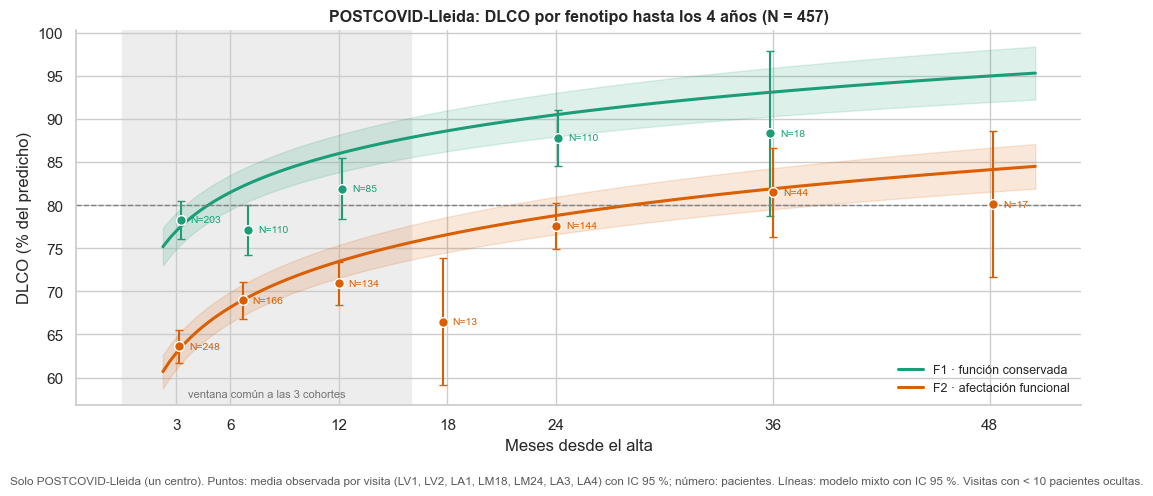

N      meses (mediana)       DLCO media      
fenotipo   F1   F2              F1    F2         F1    F2
visita                                                   
LV1       203  248             3.3   3.2       78.3  63.6
LV2       110  166             7.0   6.7       77.1  68.9
LA1        85  134            12.2  12.0       81.9  70.9
LM18      <10   13             NaN  17.7        NaN  66.5
LM24      110  144            24.1  24.0       87.8  77.6
LA3        18   44            35.9  36.0       88.3  81.5
LA4       <10   17             NaN  48.2        NaN  80.1

fenotipo,F1 · función conservada,F2 · afectación funcional,F2 − F1
meses,,,
3,77.0,62.8,-14.2 [-17.0 a -11.4]
6,81.5,68.2,-13.3 [-16.0 a -10.7]
12,86.0,73.5,-12.5 [-15.4 a -9.6]
18,88.6,76.6,-12.0 [-15.2 a -8.9]
24,90.5,78.8,-11.7 [-15.0 a -8.4]
36,93.1,81.9,-11.2 [-14.9 a -7.6]
48,95.0,84.1,-10.9 [-14.8 a -6.9]


In [11]:
EXT = TR["extension_lleida"]
fen_l = fenotipo[cohorte == "POSTCOVID_LLEIDA"]
L_ext = T.tabla_larga(medidas, fen_l, cohorte[fen_l.index], TR["variable"], (EXT["dias_min"], np.inf), DPM, MREF)
L_ext = L_ext[L_ext["visita"].isin(EXT["visitas"])]
mixto_ext, tipo_ext = T.ajustar_mixto(L_ext, FORMULA_C, TR["efectos_aleatorios"])
print(f"Lleida, extensión: {len(L_ext)} medidas de {L_ext['subject_id'].nunique()} pacientes; {tipo_ext}; convergió: {mixto_ext.converged}")

fig, ax = plt.subplots(figsize=(11, 4.8))
rej = np.linspace(np.percentile(L_ext["meses"], 2), L_ext["meses"].max(), 120)
filas = []
for f in FEN:
    pr = T.predicciones(mixto_ext, [f], list(rej), MREF)
    ax.plot(rej, pr["estimacion"], color=C_FEN[f], lw=2.2, label=NOMF[f])
    ax.fill_between(rej, pr["ic_inf"], pr["ic_sup"], color=C_FEN[f], alpha=0.15)
    for v in EXT["visitas"]:
        s = L_ext[(L_ext["fenotipo"] == f) & (L_ext["visita"] == v)]
        visible = len(s) >= N_MIN
        filas.append({"fenotipo": f, "visita": v, "N": len(s) if visible else f"<{N_MIN}",
                      "meses (mediana)": round(s["meses"].median(), 1) if visible else np.nan,
                      "DLCO media": round(s["valor"].mean(), 1) if visible else np.nan})
        if visible:
            m, lo, hi = media_ic(s["valor"]); x = s["meses"].median()
            ax.errorbar(x, m, yerr=[[m - lo], [hi - m]], fmt="o", color=C_FEN[f], mec="white", ms=7, capsize=3)
            ax.annotate(f"N={len(s)}", (x, m), textcoords="offset points", xytext=(7, 0),
                        ha="left", va="center", fontsize=7.5, color=C_FEN[f])
ax.axhline(U_DLCO, color="0.5", ls="--", lw=1); ax.axvspan(0, 16, color="0.93", zorder=0)
ax.text(8, ax.get_ylim()[0] + 1, "ventana común a las 3 cohortes", ha="center", fontsize=8, color="0.45")
ax.set_xticks([3, 6, 12, 18, 24, 36, 48]); ax.set_xlabel("Meses desde el alta"); ax.set_ylabel("DLCO (% del predicho)")
ax.set_title(f"POSTCOVID-Lleida: DLCO por fenotipo hasta los 4 años (N = {L_ext['subject_id'].nunique()})")
ax.legend(frameon=False, fontsize=9, loc="lower right")
nota(fig, "Solo POSTCOVID-Lleida (un centro). Puntos: media observada por visita (LV1, LV2, LA1, LM18, LM24, LA3, LA4) con IC 95 %; "
          "número: pacientes. Líneas: modelo mixto con IC 95 %. Visitas con < 10 pacientes ocultas.")
plt.tight_layout(); guardar(fig, "extension_lleida"); plt.show()

d_ext = T.diferencias(mixto_ext, "F1", "F2", EXT["meses_prediccion"], MREF)
p_ext = T.predicciones(mixto_ext, FEN, EXT["meses_prediccion"], MREF)
ext_tabla = p_ext.assign(v=lambda d: d["estimacion"].round(1)).pivot(index="meses", columns="fenotipo", values="v").rename(columns=NOMF)
ext_tabla["F2 − F1"] = [fmt_ic(r) for r in d_ext.to_dict("records")]
ext_tabla.to_csv(TAB / f"{PFX}_extension_lleida.csv")
display(pd.DataFrame(filas).pivot(index="visita", columns="fenotipo").reindex(EXT["visitas"]))
ext_tabla

## 9 · Sello 3 del pasaporte: ¿evolucionan distinto?

Se aplica el criterio de `config.yaml` (`trayectorias.criterio_sello`) a los resultados de §4, y se añaden las comprobaciones de robustez de §5 y §6.

In [12]:
def excluye_cero_negativo(res) -> tuple[bool, str]:
    d = T.diferencias(res, "F1", "F2", [12], MREF).iloc[0].to_dict()
    return d["ic_sup"] < 0, fmt_ic(d)


comprobaciones = [("Modelo conjunto (las tres)", mixto, True),
                  ("CIBERESUCICOVID", por_coh["CIBERESUCICOVID"][0], True),
                  ("POSTCOVID-Lleida", por_coh["POSTCOVID_LLEIDA"][0], True),
                  ("TENACITY (informativa: N pequeña)", por_coh["TENACITY"][0], False),
                  ("Sensibilidad: GEE con IPW (abandono)", gee_w, False),
                  ("Sensibilidad: sin la medida de 3 meses", mixto_post, False)]
filas = []
for nombre, res, decide in comprobaciones:
    ok, txt = excluye_cero_negativo(res)
    filas.append({"comprobación": nombre, "F2 − F1 a 12 meses [IC 95 %]": txt,
                  "IC excluye 0": "sí" if ok else "no", "cuenta para el sello": "sí" if decide else "robustez"})
sello = pd.DataFrame(filas).set_index("comprobación")
SELLO_3 = all(r["IC excluye 0"] == "sí" for r in filas if r["cuenta para el sello"] == "sí")
sello.to_csv(TAB / f"{PFX}_sello3.csv")
print(f"Criterio: {TR['criterio_sello']}")
print(f"\nSELLO 3 «evoluciona distinto»: {'SUPERADO' if SELLO_3 else 'NO SUPERADO'}")
sello

Criterio: La diferencia F2 − F1 predicha a 12 meses tiene un IC 95 % que excluye 0 en el modelo conjunto y en cada cohorte grande (CIBERESUCICOVID y Lleida)

SELLO 3 «evoluciona distinto»: SUPERADO


,F2 − F1 a 12 meses [IC 95 %],IC excluye 0,cuenta para el sello
comprobación,,,
Modelo conjunto (las tres),-11.5 [-13.6 a -9.3],sí,sí
CIBERESUCICOVID,-11.1 [-14.2 a -8.0],sí,sí
POSTCOVID-Lleida,-11.0 [-14.3 a -7.7],sí,sí
TENACITY (informativa: N pequeña),-16.5 [-24.0 a -9.0],sí,robustez
Sensibilidad: GEE con IPW (abandono),-10.4 [-13.2 a -7.6],sí,robustez
Sensibilidad: sin la medida de 3 meses,-10.9 [-13.4 a -8.5],sí,robustez


## 10 · Resumen

**Resultados (ejecución con semilla 2026; ver §1–§9).**

1. **Datos.** 1.429 pacientes con DLCO entre 30 y 480 días (2.512 medidas). De ellos, 763 tienen al menos dos medidas: una trayectoria propiamente dicha. N por punto temporal: 1.378 a ~3 meses, 577 a ~6 y 487 a ~12.
2. **Los dos fenotipos mejoran, pero no convergen (§3).** DLCO media prevista:

   | | 3 meses | 12 meses | Ganancia |
   |---|---|---|---|
   | F1 · función conservada | 79,4 % | 86,1 % | +6,7 puntos |
   | F2 · afectación funcional | 65,4 % | 74,6 % | +9,2 puntos |

   - F2 recupera algo más (+2,5 puntos [0,7–4,3], p = 0,006): una **recuperación parcial**.
   - La distancia **solo se cierra de 14,0 a 11,5 puntos** (IC 95 % a 12 meses: −13,6 a −9,3).
   - **A los 12 meses, el paciente medio de F2 sigue por debajo del 80 %.**
3. **Se reproduce en cada cohorte (§4).** Diferencia F2 − F1 a 12 meses:
   - CIBERESUCICOVID: −11,1 [−14,2 a −8,0];
   - Lleida: −11,0 [−14,3 a −7,7];
   - TENACITY: −16,5 [−24,0 a −9,0], con N pequeña y sin la recuperación adicional de F2.

   **Sello 3 «evoluciona distinto»: superado (§9).**
4. **El abandono es informativo, pero no cambia la conclusión (§5).**
   - Quien solo tiene DLCO a 3 meses partía de 76,6 %; quien hizo las tres visitas, de 67,7 %.
   - Por eso las medias brutas de quien vuelve **infravaloran la recuperación**: la ganancia de F1 es +3,8 sin pesos, +5,6 con IPW y +6,7 en el modelo mixto.
   - La diferencia entre fenotipos a 12 meses apenas se mueve: −10,0 a −11,5 según el método.
   - En TENACITY, 39 pacientes **aún no habían llegado** a la visita anual: no se cuentan como abandono.
5. **La diferencia no es regresión a la media (§6).** Sin la medida de 3 meses, que definió el fenotipo, la diferencia a 12 meses sigue en −10,9 [−13,4 a −8,5]. La recuperación adicional de F2, en cambio, casi desaparece: F2 gana +8,3 y F1 +7,6, frente a +9,2 y +6,7 en el análisis principal. Es decir:
   - **parte de la recuperación "extra" de F2 es regresión a la media**;
   - **la brecha persistente, no**.
6. **FVC.** La misma historia, más marcada: la brecha pasa de −22,4 puntos a 6 meses a −19,2 a 12 meses, y F2 gana +10,1 frente a +3,7.
7. **Transiciones (§7).**
   - A 12 meses, **el 76 % sigue en el mismo fenotipo**.
   - **Un 38 % de F2 pasa a F1** (recuperación individual). Solo un 8 % de F1 pasa a F2.
   - En Lleida, entre los 12 y los 24 meses el 86 % se mantiene estable.
   - Ojo: con estos medoides, las transiciones describen sobre todo la **FVC** (aviso de §7).
8. **Más allá del año, solo Lleida (§8).**
   - La brecha se mantiene: −12,5 puntos a 12 meses, −11,7 a 24 y −10,9 [−14,8 a −6,9] a 48.
   - F2 se acerca al 80 % hacia los **2–3 años** (78,8 % a 24 meses y 81,9 % a 36, según el modelo).
   - Es un solo centro y el N cae mucho tras los 24 meses.

**Mensaje para la consulta**
- **F1 (función conservada a 3 meses):** de media vuelve al rango normal hacia los 6 meses. Basta un control al año.
- **F2 (afectación funcional a 3 meses):**
  - mejora, pero de media **sigue alterado al año** y no alcanza a F1;
  - en Lleida no llega al 80 % hasta los 2–3 años;
  - **justifica un seguimiento más allá del primer año** y valorar rehabilitación.
- **Combinado con el notebook 08:** dentro de F2, la DLCO de los 3 meses indica quién se recuperará (≈ 60 % si está entre 70 y 79 %; < 10 % si está por debajo del 60 %).

**Limitaciones**
- **Supuesto MAR.** El modelo mixto y el IPW corrigen el abandono que depende de lo observado. No corrigen el que depende de la DLCO futura no medida (MNAR).
- **Diferencia a 3 meses por construcción.** El fenotipo se definió con la función de esa visita. Lo informativo es la evolución posterior (§6 lo comprueba).
- **Forma de la curva.** El modelo es lineal en log(tiempo). Se ajusta bien a las medias observadas hasta el año. En Lleida, más allá de 2 años, la forma es una suposición con pocos datos.
- **Medoides con huecos** (§7). Las transiciones reflejan sobre todo la FVC.
- **TENACITY es pequeña** y sigue reclutando. **Lleida es un solo centro.**
- **El criterio operativo del sello** (`config.yaml → trayectorias.criterio_sello`) se escribió al preparar este notebook a partir del `CLAUDE.md`, tras una exploración inicial del modelo. No es un criterio ciego.